In [2]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("sagara9595/stock-data")
print("Path to dataset files:", path)

Defaulting to user installation because normal site-packages is not writeable


100%|███████████████████████████████████████████████████████████████████████████████| 273M/273M [00:22<00:00, 12.7MB/s]

Extracting files...


Path to dataset files: C:\Users\Anjali\.cache\kagglehub\datasets\sagara9595\stock-data\versions\1


In [1]:
!pip install pandas matplotlib seaborn scikit-learn statsmodels tensorflow yfinance  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Set style
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

In [11]:
data_path = './Datas/'
reliance_file = 'RELIANCE.NS.csv'
infy_file = 'INFY.NS.csv'

In [12]:
# Load Reliance
df_rel = pd.read_csv(data_path + reliance_file)
df_rel['Date'] = pd.to_datetime(df_rel['Date'])
df_rel.set_index('Date', inplace=True)
df_rel = df_rel.sort_index()  # Chronological order

# Load Infosys (similar)
df_infy = pd.read_csv(data_path + infy_file)
df_infy['Date'] = pd.to_datetime(df_infy['Date'])
df_infy.set_index('Date', inplace=True)
df_infy = df_infy.sort_index()

print("Reliance Shape:", df_rel.shape)
print("Infosys Shape:", df_infy.shape)
df_rel.head()  # Preview

Reliance Shape: (5045, 6)
Infosys Shape: (5044, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,37.095798,39.313702,37.095798,39.313702,16.380438,28531559
2000-01-04,40.360199,42.460999,39.251301,42.460999,17.691788,60744659
2000-01-05,40.086899,44.967899,40.086899,44.124500,18.384905,171798476
2000-01-06,45.139702,46.967201,45.139702,45.975300,19.156059,100403390
2000-01-07,46.076900,49.653702,45.764500,49.130402,20.470661,127220830


In [13]:
# Compute Daily Returns
df_rel['Returns'] = df_rel['Close'].pct_change() * 100  # % change
df_infy['Returns'] = df_infy['Close'].pct_change() * 100

# Volatility (Rolling Std Dev)
df_rel['Volatility'] = df_rel['Returns'].rolling(window=30).std()  # 30-day
df_infy['Volatility'] = df_infy['Returns'].rolling(window=30).std()

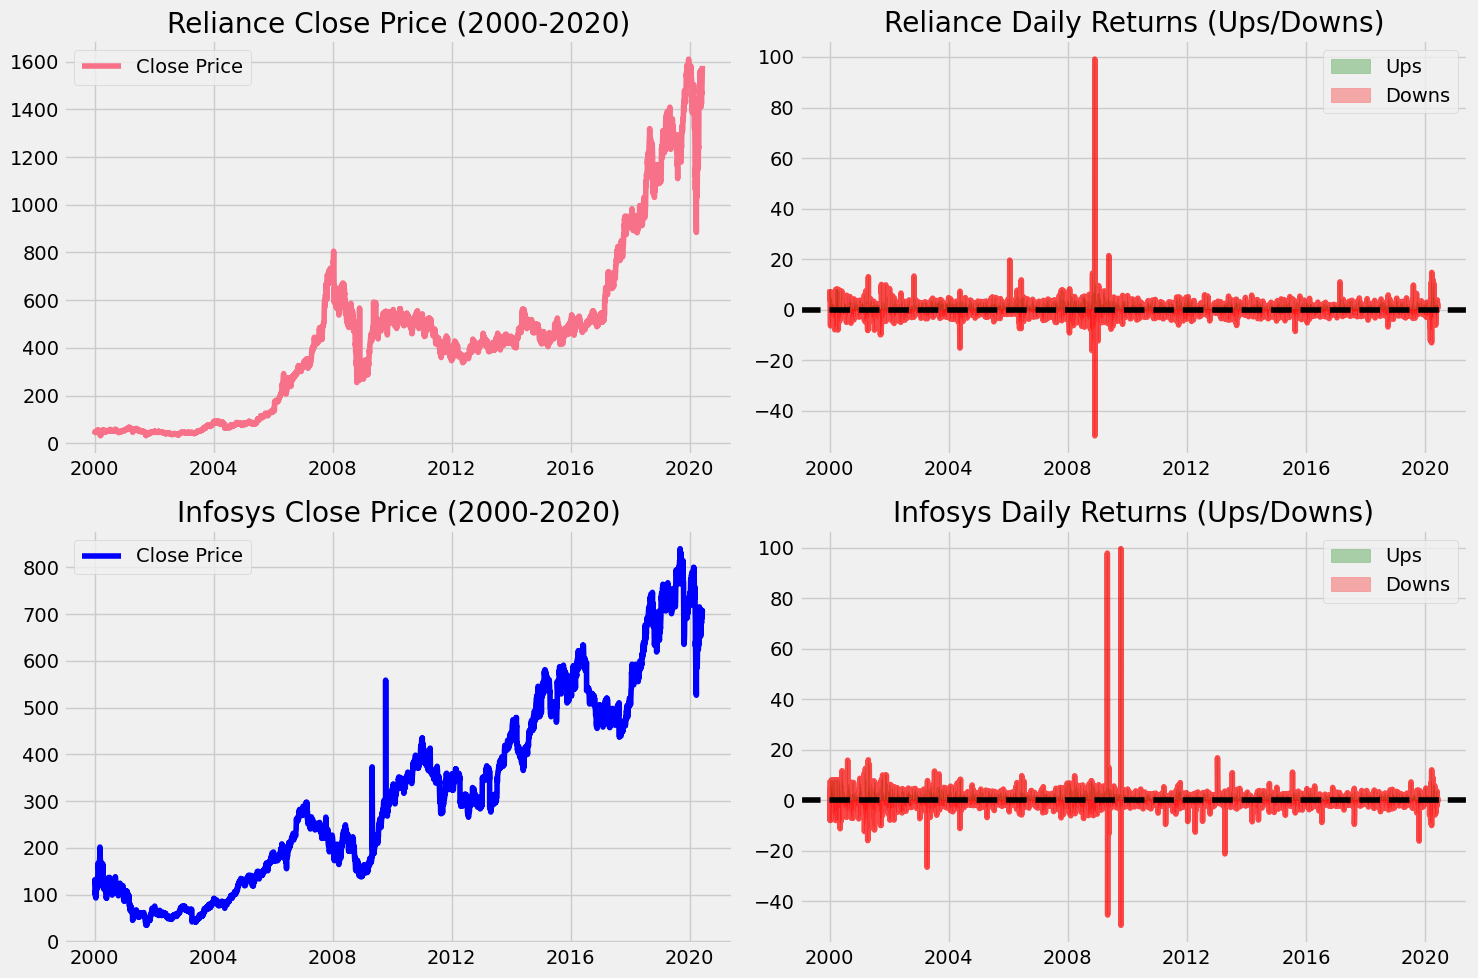

In [14]:
# Plot Close Prices (Ups/Downs Trends)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Reliance Close & Returns
axes[0,0].plot(df_rel.index, df_rel['Close'], label='Close Price')
axes[0,0].set_title('Reliance Close Price (2000-2020)')
axes[0,0].legend()

axes[0,1].plot(df_rel.index, df_rel['Returns'], color='red', alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='--')
axes[0,1].set_title('Reliance Daily Returns (Ups/Downs)')
axes[0,1].fill_between(df_rel.index, df_rel['Returns'], where=(df_rel['Returns'] > 0), alpha=0.3, color='green', label='Ups')
axes[0,1].fill_between(df_rel.index, df_rel['Returns'], where=(df_rel['Returns'] < 0), alpha=0.3, color='red', label='Downs')
axes[0,1].legend()

# Infosys similar
axes[1,0].plot(df_infy.index, df_infy['Close'], label='Close Price', color='blue')
axes[1,0].set_title('Infosys Close Price (2000-2020)')
axes[1,0].legend()

axes[1,1].plot(df_infy.index, df_infy['Returns'], color='red', alpha=0.7)
axes[1,1].axhline(y=0, color='black', linestyle='--')
axes[1,1].set_title('Infosys Daily Returns (Ups/Downs)')
axes[1,1].fill_between(df_infy.index, df_infy['Returns'], where=(df_infy['Returns'] > 0), alpha=0.3, color='green', label='Ups')
axes[1,1].fill_between(df_infy.index, df_infy['Returns'], where=(df_infy['Returns'] < 0), alpha=0.3, color='red', label='Downs')
axes[1,1].legend()

plt.tight_layout()
plt.show()

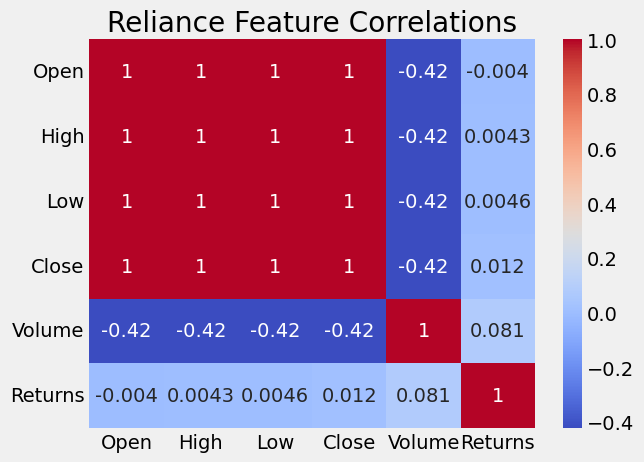

In [15]:
# Correlation Heatmap
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns']
corr_rel = df_rel[features].corr()
sns.heatmap(corr_rel, annot=True, cmap='coolwarm')
plt.title('Reliance Feature Correlations')
plt.show()

In [20]:
# Key Insights Print
print("Reliance Avg Return:", round(df_rel['Returns'].mean(), 2), "%")
print("Reliance Max Drawdown (Biggest Down):", round(df_rel['Returns'].min(), 2), "%")
print("Reliance Volatility (30d Std):", round(df_rel['Volatility'].mean(), 2), "%")

Reliance Avg Return: 0.11 %
Reliance Max Drawdown (Biggest Down): -49.98 %
Reliance Volatility (30d Std): 2.08 %


In [17]:
# Prep Data (Use Reliance for demo)
data = df_rel['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [18]:
# Create Sequences (Lookback=60 days)
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 60
X, y = create_sequences(scaled_data, lookback)
X = X.reshape((X.shape[0], X.shape[1], 1))  # LSTM input shape

In [19]:
# Train/Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(lookback, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Predict
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform([y_test])

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_inv[0], y_pred[:,0]))
mae = mean_absolute_error(y_test_inv[0], y_pred[:,0])
print(f"LSTM RMSE: {rmse:.2f}, MAE: {mae:.2f}")

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0029 - val_loss: 1.8394e-04
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 1.5083e-04 - val_loss: 1.1648e-04
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 1.3989e-04 - val_loss: 1.4427e-04
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 1.3656e-04 - val_loss: 1.4516e-04
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 1.2296e-04 - val_loss: 1.0283e-04
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 1.2028e-04 - val_loss: 1.0276e-04
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 1.1946e-04 - val_loss: 1.0576e-04
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 1.0892e-04 - val_loss: 1.0241e-04
Epoch 9/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 1.0552e-04 - val_loss: 7.8027e-05
Epoch 10/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 1.0482e-04 - val_loss: 1.1899e-04
Epoch 11/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1

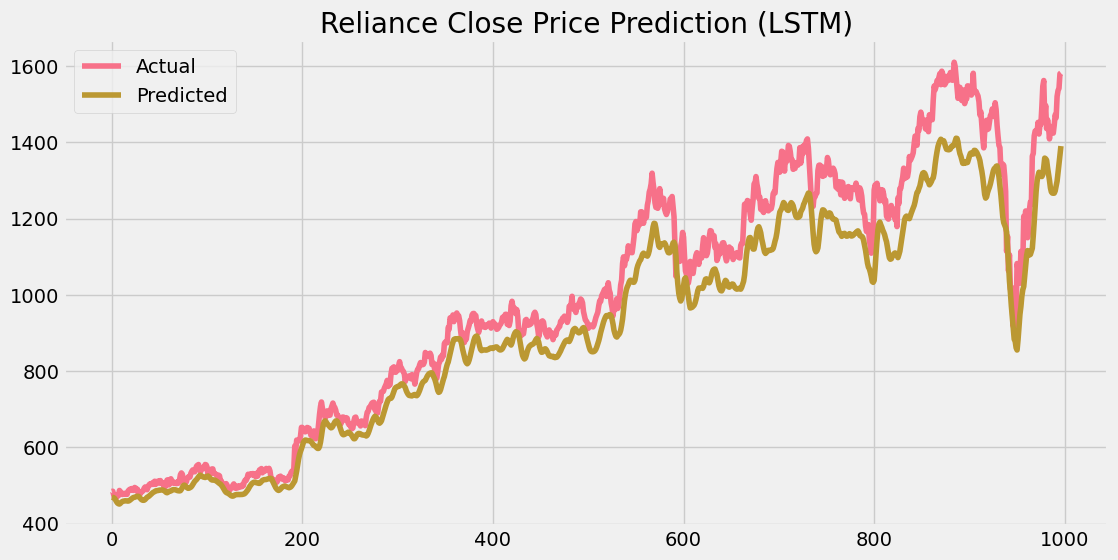

In [21]:
# Plot Predictions
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[0], label='Actual')
plt.plot(y_pred[:,0], label='Predicted')
plt.title('Reliance Close Price Prediction (LSTM)')
plt.legend()
plt.show()

In [22]:
# Baseline: ARIMA
arima_model = ARIMA(df_rel['Close'][:split + lookback], order=(5,1,0))  # Adjust order; fixed index
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(X_test))
arima_rmse = np.sqrt(mean_squared_error(y_test_inv[0], arima_pred))
print(f"ARIMA RMSE: {arima_rmse:.2f}")

ARIMA RMSE: 596.33


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

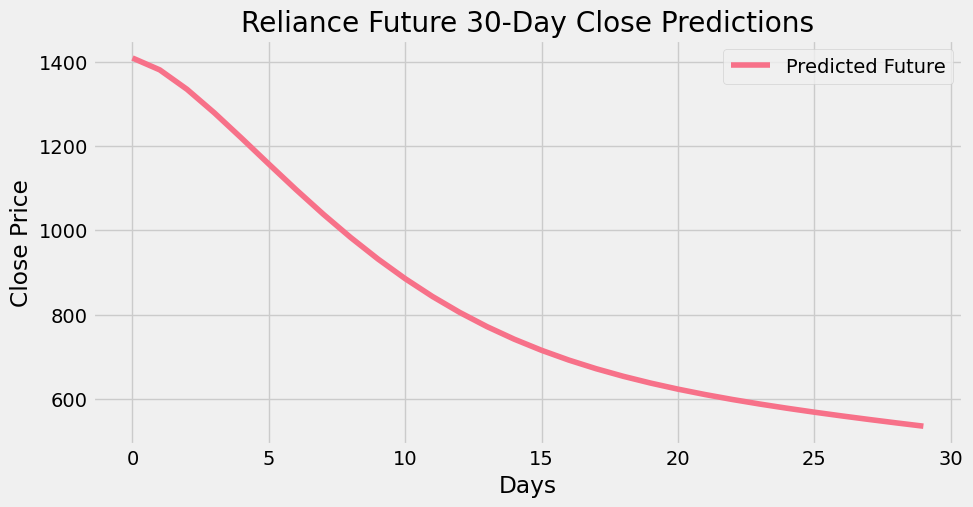

In [26]:
# Use last 60 days for input
last_seq = scaled_data[-lookback:].reshape(1, lookback, 1)
future_preds = []
for _ in range(30):
    pred = model.predict(last_seq)
    future_preds.append(pred[0,0])
    last_seq = np.roll(last_seq, -1, axis=1)
    last_seq[0, -1, 0] = pred[0,0]

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
print("Predicted Next 30 Days Closes:", future_preds.flatten()[:5])  # First 5

# Plot Predictions
plt.figure(figsize=(10,5))
plt.plot(range(30), future_preds, label='Predicted Future')
plt.title('Reliance Future 30-Day Close Predictions')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()